In [2]:
library(ape)
library(TreeSim)
library(TreeTools)
library(RColorBrewer)

### 1. Helper functions

In [3]:
# helper function to create eGRM for a single branch

eGRM <- function(x) {
    n <- length(x)
    x_mean <- mean(x)
    x_sd <- sqrt(sum((x - x_mean) ^ 2) / n)
    x_tilde <- (x - x_mean) / x_sd
    return(outer(x_tilde, x_tilde))
}

### 2. Felsenstein's worst case

In [4]:
s1 = stree(10, type = "star")
s2 = stree(10, type = "star")

s1$tip.label = paste(s1$tip.label,"_1")
s2$tip.label = paste(s2$tip.label,"_2")

s1$edge.length=rep(1,length(s1$tip.label))
s2$edge.length=rep(1,length(s2$tip.label))

s1$root.edge=10
s2$root.edge=10

combined_tree = s1 + s2

In [5]:
n_tips = length(combined_tree$tip.label)

n_branches = length(combined_tree$edge[, 1])

G <- matrix(0, nrow = n_branches, ncol = n_tips)
for (i in 1:n_branches) {
    node_needed = combined_tree$edge[i, 2]
    descendants = getDescendants(combined_tree, node_needed)
    descendants_needed = descendants[descendants <= n_tips]
    G[i, descendants_needed] = 1
}

In [6]:
sum_weights <- sum(combined_tree$edge.length)

branch <- G[1, ]
eGRM_0 <- eGRM(branch)
weight <- combined_tree$edge.length[1] / sum_weights
eGRMs_vec <- as.vector(eGRM_0) * weight
for (i in 2:n_branches) {
    branch <- G[i, ]
    eGRM_0 <- eGRM(branch)
    weight <- combined_tree$edge.length[i] / sum_weights
    eGRMs_vec <- cbind(eGRMs_vec, as.vector(eGRM_0) * weight)
}

df1 <- as.data.frame(eGRMs_vec)
colnames(df1) <- paste0("eGRM", 1:n_branches)
df1$eGRM_tot <- rowSums(df1)
eGRM_tot <- matrix(df1$eGRM_tot, nrow = n_tips, byrow = TRUE)

PCs = eigen(eGRM_tot)$vectors
lambdas = eigen(eGRM_tot)$values

Sigma1 = outer(PCs[,1], PCs[,1])
df1$Sigma1 <- as.vector(Sigma1)

In [7]:
# Fit linear model
eGRM_names_2 <- paste0("eGRM", 2:22)
str_formula <- paste(c("Sigma1 ~ eGRM1", eGRM_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df1)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_felsenstein_eGRM <- as.vector(coeffs)
n_eGRM_same = which(is.na(branch_values_felsenstein_eGRM))
branch_values_felsenstein_eGRM[1] <- branch_values_felsenstein_eGRM[1] / 2
branch_values_felsenstein_eGRM[n_eGRM_same] <- branch_values_felsenstein_eGRM[1]

In [14]:
branch <- G[1, ]
VCV_0 <- outer(branch, branch)
weight <- combined_tree$edge.length[1]
VCVs_vec <- as.vector(VCV_0) * weight
for (i in 2:n_branches) {
    branch <- G[i, ]
    VCV_0 <- outer(branch, branch)
    weight <- combined_tree$edge.length[i]
    VCVs_vec <- cbind(VCVs_vec, as.vector(VCV_0) * weight)
}

df2 <- as.data.frame(VCVs_vec)
colnames(df2) <- paste0("VCV", 1:n_branches)
df2$VCV_tot <- rowSums(df2)
VCV_tot <- matrix(df2$VCV_tot, nrow = n_tips, byrow = TRUE)

PCs = eigen(VCV_tot)$vectors
lambdas = eigen(VCV_tot)$values

Sigma1 = outer(PCs[,1], PCs[,1])
df2$Sigma1 <- as.vector(Sigma1)

In [15]:
# Fit linear model
VCV_names_2 <- paste0("VCV", 2:22)
str_formula <- paste(c("Sigma1 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df2)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_felsenstein_VCV <- as.vector(coeffs)

In [16]:
C_N <- diag(n_tips) - 1 / n_tips * matrix(1, nrow = n_tips, ncol = n_tips)
branch <- G[1, ]
VCV_0 <- C_N %*% outer(branch, branch) %*% C_N
weight <- combined_tree$edge.length[1]
VCVs_vec <- as.vector(VCV_0) * weight
for (i in 2:n_branches) {
    branch <- G[i, ]
    VCV_0 <- C_N %*% outer(branch, branch) %*% C_N
    weight <- combined_tree$edge.length[i]
    VCVs_vec <- cbind(VCVs_vec, as.vector(VCV_0) * weight)
}

df3 <- as.data.frame(VCVs_vec)
colnames(df3) <- paste0("VCV", 1:n_branches)
df3$VCV_tot <- rowSums(df3)
VCV_tot <- matrix(df3$VCV_tot, nrow = n_tips, byrow = TRUE)

PCs = eigen(VCV_tot)$vectors
lambdas = eigen(VCV_tot)$values

Sigma1 = outer(PCs[,1], PCs[,1])
df3$Sigma1 <- as.vector(Sigma1)

In [17]:
# Fit linear model
VCV_names_2 <- paste0("VCV", 2:22)
str_formula <- paste(c("Sigma1 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df3)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_felsenstein_dcVCV <- as.vector(coeffs)
n_dcVCV_same = which(is.na(branch_values_felsenstein_dcVCV))
branch_values_felsenstein_dcVCV[1] <- branch_values_felsenstein_dcVCV[1] / 2
branch_values_felsenstein_dcVCV[n_dcVCV_same] <- branch_values_felsenstein_dcVCV[1]

### 3. Plotting

In [18]:
# Create color mapping
n_colors <- 100
value_max_1_1 <- max(abs(branch_values_felsenstein_eGRM))
value_max_1_2 <- max(abs(branch_values_felsenstein_VCV))
value_max_1_3 <- max(abs(branch_values_felsenstein_dcVCV))
color_breaks_1_1 <- seq(-value_max_1_1, value_max_1_1, length.out = n_colors + 1)
color_breaks_1_2 <- seq(-value_max_1_2, value_max_1_2, length.out = n_colors + 1)
color_breaks_1_3 <- seq(-value_max_1_3, value_max_1_3, length.out = n_colors + 1)
color_palette <- colorRampPalette(c("#364B9A", "#4A7BB7", "#6EA6CD", "#98CAE1", 
                                    "#C2E4EF", "#EAECCC", "#FEDA8B", "#FDB366", 
                                    "#F67E4B", "#DD3D2D", "#A50026"))(n_colors)

# Assign colors to branches based on where each value falls in the scale
branch_colors_felsenstein_eGRM <- color_palette[findInterval(branch_values_felsenstein_eGRM, 
                                                             color_breaks_1_1, 
                                                             rightmost.closed = TRUE)]
branch_colors_felsenstein_VCV <- color_palette[findInterval(branch_values_felsenstein_VCV, 
                                                            color_breaks_1_2, 
                                                            rightmost.closed = TRUE)]
branch_colors_felsenstein_dcVCV <- color_palette[findInterval(branch_values_felsenstein_dcVCV, 
                                                              color_breaks_1_3, 
                                                              rightmost.closed = TRUE)]

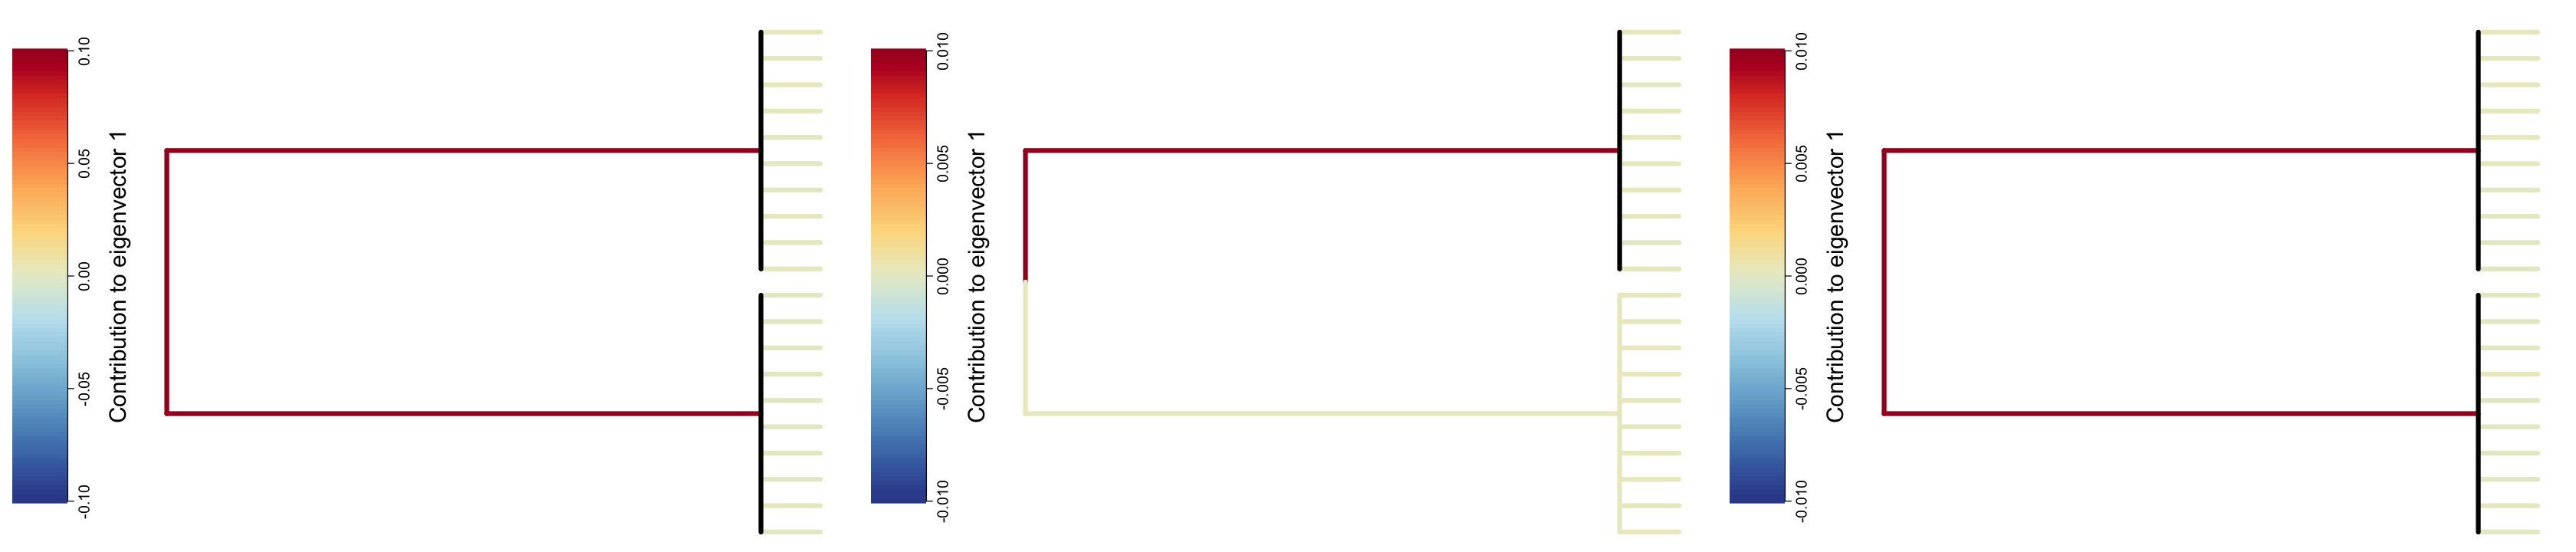

In [45]:
# Plot the trees
options(repr.plot.width = 28, repr.plot.height = 6)
layout(matrix(1:6, nrow = 1, byrow = TRUE), widths = c(3, 35, 3, 35, 3, 35)) 

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_1_1, z = matrix(color_breaks_1_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)

par(mar = c(0, 6, 1, 1))
plot.phylo(combined_tree, edge.color = branch_colors_felsenstein_eGRM, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_1_2, z = matrix(color_breaks_1_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)

par(mar = c(0, 6, 1, 1))
plot.phylo(combined_tree, edge.color = branch_colors_felsenstein_VCV, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_1_3, z = matrix(color_breaks_1_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)

par(mar = c(0, 6, 1, 1))
plot.phylo(combined_tree, edge.color = branch_colors_felsenstein_dcVCV, 
           edge.width = 5, show.tip.label = FALSE)

In [46]:
svg("Figures_raw/supplement_PC_contributions_1.svg", width = 28, height = 6)

layout(matrix(1:6, nrow = 1, byrow = TRUE), widths = c(3, 35, 3, 35, 3, 35)) 

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_1_1, z = matrix(color_breaks_1_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)

par(mar = c(0, 6, 1, 1))
plot.phylo(combined_tree, edge.color = branch_colors_felsenstein_eGRM, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_1_2, z = matrix(color_breaks_1_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)

par(mar = c(0, 6, 1, 1))
plot.phylo(combined_tree, edge.color = branch_colors_felsenstein_VCV, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_1_3, z = matrix(color_breaks_1_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)

par(mar = c(0, 6, 1, 1))
plot.phylo(combined_tree, edge.color = branch_colors_felsenstein_dcVCV, 
           edge.width = 5, show.tip.label = FALSE)

dev.off()

pdf 
  2

In [47]:
pdf("Figures_raw/supplement_PC_contributions_1.pdf", width = 28, height = 6)

layout(matrix(1:6, nrow = 1, byrow = TRUE), widths = c(3, 35, 3, 35, 3, 35)) 

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_1_1, z = matrix(color_breaks_1_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)

par(mar = c(0, 6, 1, 1))
plot.phylo(combined_tree, edge.color = branch_colors_felsenstein_eGRM, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_1_2, z = matrix(color_breaks_1_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)

par(mar = c(0, 6, 1, 1))
plot.phylo(combined_tree, edge.color = branch_colors_felsenstein_VCV, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_1_3, z = matrix(color_breaks_1_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)

par(mar = c(0, 6, 1, 1))
plot.phylo(combined_tree, edge.color = branch_colors_felsenstein_dcVCV, 
           edge.width = 5, show.tip.label = FALSE)

dev.off()

pdf 
  2

### 4. Yule Tree

In [22]:
set.seed(123)

n_tips = 10
yule_tree = sim.bd.taxa(n_tips, 1, 1, 0, 1, complete = FALSE)[[1]]

n_branches = length(yule_tree$edge[, 1])

G <- matrix(0, nrow = n_branches, ncol = n_tips)
for (i in 1:n_branches) {
    node_needed = yule_tree$edge[i, 2]
    descendants = getDescendants(yule_tree, node_needed)
    descendants_needed = descendants[descendants <= n_tips]
    G[i, descendants_needed] = 1
}

In [23]:
sum_weights <- sum(yule_tree$edge.length)

branch <- G[1, ]
eGRM_0 <- eGRM(branch)
weight <- yule_tree$edge.length[1] / sum_weights
eGRMs_vec <- as.vector(eGRM_0) * weight
for (i in 2:n_branches) {
    branch <- G[i, ]
    eGRM_0 <- eGRM(branch)
    weight <- yule_tree$edge.length[i] / sum_weights
    eGRMs_vec <- cbind(eGRMs_vec, as.vector(eGRM_0) * weight)
}

df4 <- as.data.frame(eGRMs_vec)
colnames(df4) <- paste0("eGRM", 1:n_branches)
df4$eGRM_tot <- rowSums(df4)
eGRM_tot <- matrix(df4$eGRM_tot, nrow = n_tips, byrow = TRUE)

PCs = eigen(eGRM_tot)$vectors
lambdas = eigen(eGRM_tot)$values

Sigma_names <- paste0("Sigma", 1:n_tips)
for (i in 1:n_tips) {
    Sigma = outer(PCs[,i], PCs[,i])
    name = Sigma_names[i]
    df4[[name]] = as.vector(Sigma)
}

In [24]:
# Fit linear model
eGRM_names_2 <- paste0("eGRM", 2:n_branches)
str_formula <- paste(c("Sigma1 ~ eGRM1", eGRM_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df4)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_yule_eGRM_1 <- as.vector(coeffs)
n_eGRM_same_1 = which(is.na(branch_values_yule_eGRM_1))
branch_values_yule_eGRM_1[1] <- branch_values_yule_eGRM_1[1] / 2
branch_values_yule_eGRM_1[n_eGRM_same_1] <- branch_values_yule_eGRM_1[1]

# Fit linear model
str_formula <- paste(c("Sigma2 ~ eGRM1", eGRM_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df4)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_yule_eGRM_2 <- as.vector(coeffs)
n_eGRM_same_2 = which(is.na(branch_values_yule_eGRM_2))
branch_values_yule_eGRM_2[1] <- branch_values_yule_eGRM_2[1] / 2
branch_values_yule_eGRM_2[n_eGRM_same_2] <- branch_values_yule_eGRM_2[1]

# Fit linear model
str_formula <- paste(c("Sigma3 ~ eGRM1", eGRM_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df4)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_yule_eGRM_3 <- as.vector(coeffs)
n_eGRM_same_3 = which(is.na(branch_values_yule_eGRM_3))
branch_values_yule_eGRM_3[1] <- branch_values_yule_eGRM_3[1] / 2
branch_values_yule_eGRM_3[n_eGRM_same_3] <- branch_values_yule_eGRM_3[1]

In [25]:
sum_weights <- sum(yule_tree$edge.length)

branch <- G[1, ]
VCV_0 <- outer(branch, branch)
weight <- yule_tree$edge.length[1]
VCVs_vec <- as.vector(VCV_0) * weight
for (i in 2:n_branches) {
    branch <- G[i, ]
    VCV_0 <- outer(branch, branch)
    weight <- yule_tree$edge.length[i]
    VCVs_vec <- cbind(VCVs_vec, as.vector(VCV_0) * weight)
}

df5 <- as.data.frame(VCVs_vec)
colnames(df5) <- paste0("VCV", 1:n_branches)

df5$VCV_tot <- rowSums(df5)
VCV_tot <- matrix(df5$VCV_tot, nrow = n_tips, byrow = TRUE)

PCs = eigen(VCV_tot)$vectors
lambdas = eigen(VCV_tot)$values

Sigma_names <- paste0("Sigma", 1:n_tips)
for (i in 1:n_tips) {
    Sigma = outer(PCs[,i], PCs[,i])
    name = Sigma_names[i]
    df5[[name]] = as.vector(Sigma)
}

In [26]:
# Fit linear model
VCV_names_2 <- paste0("VCV", 2:n_branches)
str_formula <- paste(c("Sigma1 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df5)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_yule_VCV_1 <- as.vector(coeffs)

# Fit linear model
str_formula <- paste(c("Sigma2 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df5)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_yule_VCV_2 <- as.vector(coeffs)

# Fit linear model
str_formula <- paste(c("Sigma3 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df5)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_yule_VCV_3 <- as.vector(coeffs)

In [27]:
sum_weights <- sum(yule_tree$edge.length)

C_N <- diag(n_tips) - 1 / n_tips * matrix(1, nrow = n_tips, ncol = n_tips)
branch <- G[1, ]
VCV_0 <- C_N %*% outer(branch, branch) %*% C_N
weight <- yule_tree$edge.length[1]
VCVs_vec <- as.vector(VCV_0) * weight
for (i in 2:n_branches) {
    branch <- G[i, ]
    VCV_0 <- C_N %*% outer(branch, branch) %*% C_N
    weight <- yule_tree$edge.length[i]
    VCVs_vec <- cbind(VCVs_vec, as.vector(VCV_0) * weight)
}

df6 <- as.data.frame(VCVs_vec)
colnames(df6) <- paste0("VCV", 1:n_branches)

df6$VCV_tot <- rowSums(df6)
VCV_tot <- matrix(df6$VCV_tot, nrow = n_tips, byrow = TRUE)

new_PCs = eigen(VCV_tot)$vectors

new_Sigma_names <- paste0("Sigma", 1:n_tips)
for (i in 1:n_tips) {
    new_Sigma = outer(new_PCs[,i], new_PCs[,i])
    name = new_Sigma_names[i]
    df6[[name]] = as.vector(new_Sigma)
}

In [28]:
# Fit linear model
VCV_names_2 <- paste0("VCV", 2:n_branches)
str_formula <- paste(c("Sigma1 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df6)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_yule_dcVCV_1 <- as.vector(coeffs)
n_dcVCV_same_1 = which(is.na(branch_values_yule_dcVCV_1))
branch_values_yule_dcVCV_1[1] <- branch_values_yule_dcVCV_1[1] / 2
branch_values_yule_dcVCV_1[n_dcVCV_same_1] <- branch_values_yule_dcVCV_1[1]

# Fit linear model
str_formula <- paste(c("Sigma2 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df6)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_yule_dcVCV_2 <- as.vector(coeffs)
n_dcVCV_same_2 = which(is.na(branch_values_yule_dcVCV_2))
branch_values_yule_dcVCV_2[1] <- branch_values_yule_dcVCV_2[1] / 2
branch_values_yule_dcVCV_2[n_dcVCV_same_2] <- branch_values_yule_dcVCV_2[1]

# Fit linear model
str_formula <- paste(c("Sigma3 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df6)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_yule_dcVCV_3 <- as.vector(coeffs)
n_dcVCV_same_3 = which(is.na(branch_values_yule_dcVCV_3))
branch_values_yule_dcVCV_3[1] <- branch_values_yule_dcVCV_3[1] / 2
branch_values_yule_dcVCV_3[n_dcVCV_same_3] <- branch_values_yule_dcVCV_3[1]

### 5. Plotting

In [29]:
# Create color mapping
n_colors <- 100
value_max_2_1 <- max(abs(branch_values_yule_eGRM_1))
value_max_2_2 <- max(abs(branch_values_yule_VCV_1))
value_max_2_3 <- max(abs(branch_values_yule_dcVCV_1))
color_breaks_2_1 <- seq(-value_max_2_1, value_max_2_1, length.out = n_colors + 1)
color_breaks_2_2 <- seq(-value_max_2_2, value_max_2_2, length.out = n_colors + 1)
color_breaks_2_3 <- seq(-value_max_2_3, value_max_2_3, length.out = n_colors + 1)
value_max_3_1 <- max(abs(branch_values_yule_eGRM_2))
value_max_3_2 <- max(abs(branch_values_yule_VCV_2))
value_max_3_3 <- max(abs(branch_values_yule_dcVCV_2))
color_breaks_3_1 <- seq(-value_max_3_1, value_max_3_1, length.out = n_colors + 1)
color_breaks_3_2 <- seq(-value_max_3_2, value_max_3_2, length.out = n_colors + 1)
color_breaks_3_3 <- seq(-value_max_3_3, value_max_3_3, length.out = n_colors + 1)
value_max_4_1 <- max(abs(branch_values_yule_eGRM_3))
value_max_4_2 <- max(abs(branch_values_yule_VCV_3))
value_max_4_3 <- max(abs(branch_values_yule_dcVCV_3))
color_breaks_4_1 <- seq(-value_max_4_1, value_max_4_1, length.out = n_colors + 1)
color_breaks_4_2 <- seq(-value_max_4_2, value_max_4_2, length.out = n_colors + 1)
color_breaks_4_3 <- seq(-value_max_4_3, value_max_4_3, length.out = n_colors + 1)
color_palette <- colorRampPalette(c("#364B9A", "#4A7BB7", "#6EA6CD", "#98CAE1", 
                                    "#C2E4EF", "#EAECCC", "#FEDA8B", "#FDB366", 
                                    "#F67E4B", "#DD3D2D", "#A50026"))(n_colors)

# Assign colors to branches based on where each value falls in the scale
branch_colors_yule_eGRM_1 <- color_palette[findInterval(branch_values_yule_eGRM_1, 
                                                        color_breaks_2_1, 
                                                        rightmost.closed = TRUE)]
branch_colors_yule_VCV_1 <- color_palette[findInterval(branch_values_yule_VCV_1, 
                                                       color_breaks_2_2, 
                                                       rightmost.closed = TRUE)]
branch_colors_yule_dcVCV_1 <- color_palette[findInterval(branch_values_yule_dcVCV_1, 
                                                         color_breaks_2_3, 
                                                         rightmost.closed = TRUE)]
branch_colors_yule_eGRM_2 <- color_palette[findInterval(branch_values_yule_eGRM_2, 
                                                        color_breaks_3_1, 
                                                        rightmost.closed = TRUE)]
branch_colors_yule_VCV_2 <- color_palette[findInterval(branch_values_yule_VCV_2, 
                                                       color_breaks_3_2, 
                                                       rightmost.closed = TRUE)]
branch_colors_yule_dcVCV_2 <- color_palette[findInterval(branch_values_yule_dcVCV_2, 
                                                         color_breaks_3_3, 
                                                         rightmost.closed = TRUE)]
branch_colors_yule_eGRM_3 <- color_palette[findInterval(branch_values_yule_eGRM_3, 
                                                        color_breaks_4_1, 
                                                        rightmost.closed = TRUE)]
branch_colors_yule_VCV_3 <- color_palette[findInterval(branch_values_yule_VCV_3, 
                                                       color_breaks_4_2, 
                                                       rightmost.closed = TRUE)]
branch_colors_yule_dcVCV_3 <- color_palette[findInterval(branch_values_yule_dcVCV_3, 
                                                         color_breaks_4_3, 
                                                         rightmost.closed = TRUE)]

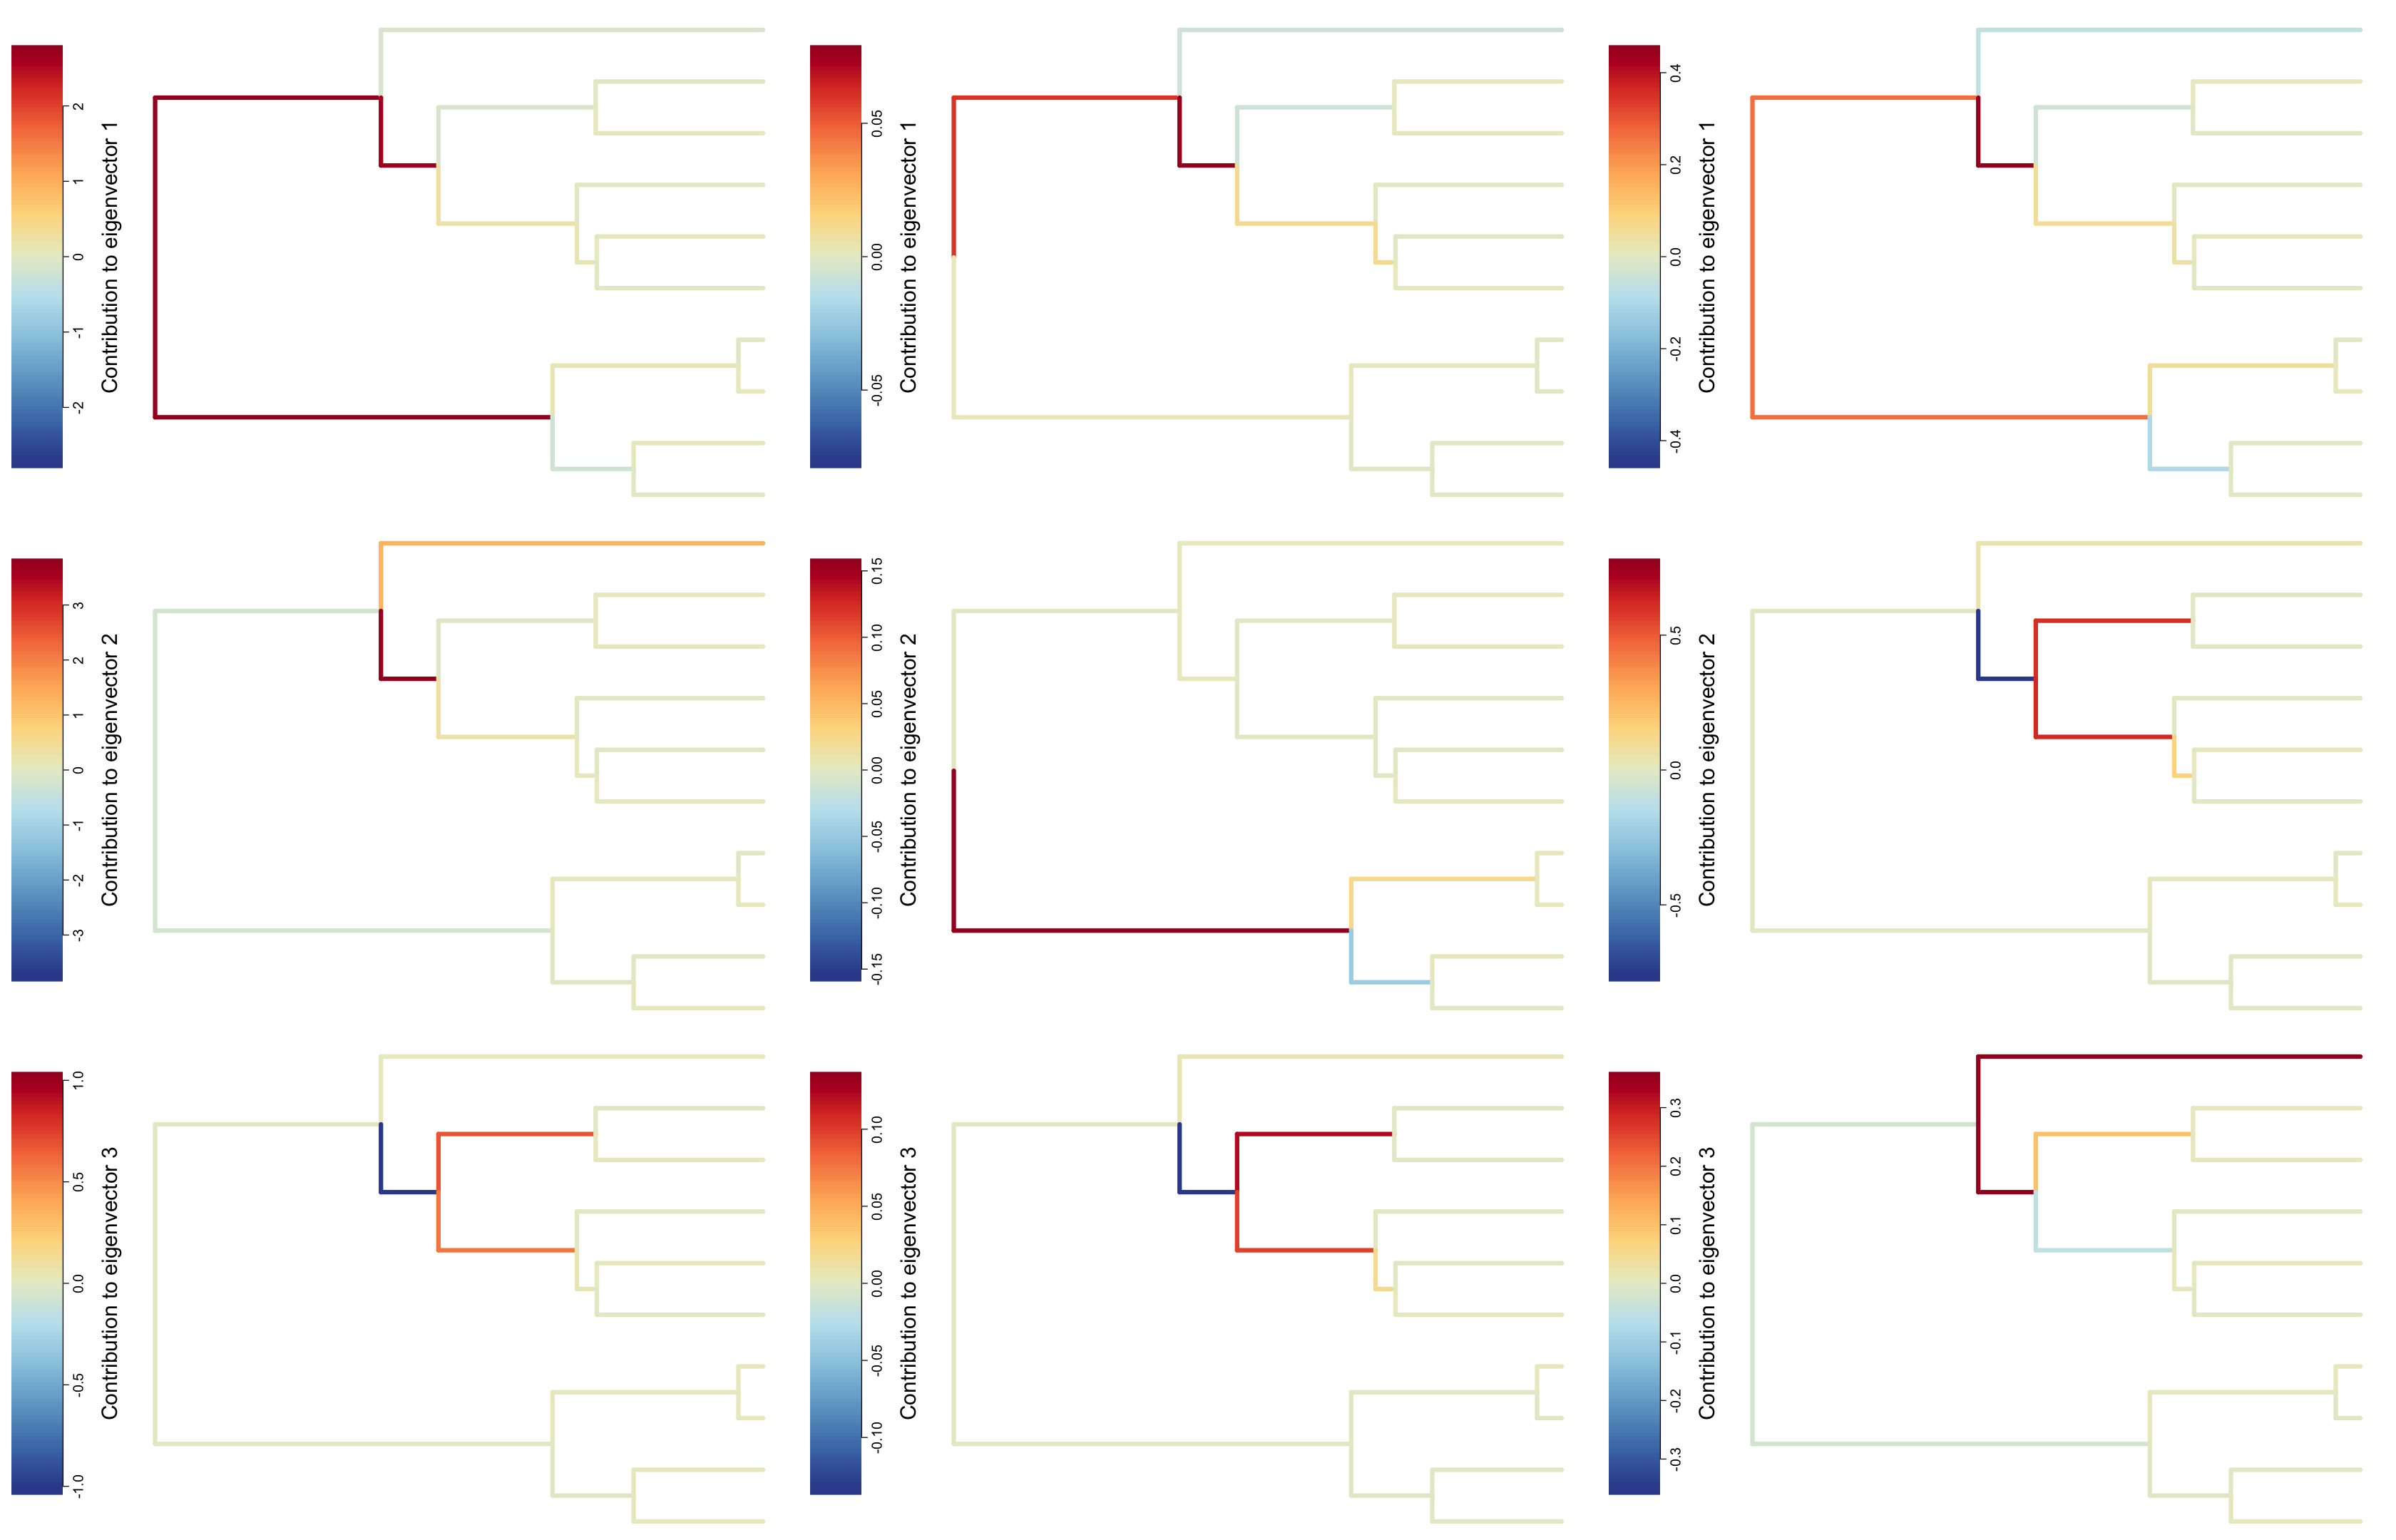

In [48]:
options(repr.plot.width = 28, repr.plot.height = 18)
layout(matrix(1:18, nrow = 3, byrow = TRUE), widths = c(3, 35, 3, 35, 3, 35)) 

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_1, z = matrix(color_breaks_2_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_eGRM_1, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_2, z = matrix(color_breaks_2_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_VCV_1, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_3, z = matrix(color_breaks_2_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_dcVCV_1, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_3_1, z = matrix(color_breaks_3_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 2", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_eGRM_2, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_3_2, z = matrix(color_breaks_3_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 2", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_VCV_2, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_3_3, z = matrix(color_breaks_3_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 2", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_dcVCV_2, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_4_1, z = matrix(color_breaks_4_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 3", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_eGRM_3, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_4_2, z = matrix(color_breaks_4_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 3", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_VCV_3, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_4_3, z = matrix(color_breaks_4_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 3", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_dcVCV_3, 
           edge.width = 5, show.tip.label = FALSE)

In [56]:
svg("Figures_raw/supplement_PC_contributions_2.svg", width = 28, height = 18)
layout(matrix(1:18, nrow = 3, byrow = TRUE), widths = c(3, 35, 3, 35, 3, 35)) 

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_1, z = matrix(color_breaks_2_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_eGRM_1, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_2, z = matrix(color_breaks_2_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_VCV_1, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_3, z = matrix(color_breaks_2_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_dcVCV_1, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_3_1, z = matrix(color_breaks_3_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 2", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_eGRM_2, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_3_2, z = matrix(color_breaks_3_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 2", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_VCV_2, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_3_3, z = matrix(color_breaks_3_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 2", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_dcVCV_2, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_4_1, z = matrix(color_breaks_4_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 3", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_eGRM_3, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_4_2, z = matrix(color_breaks_4_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 3", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_VCV_3, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_4_3, z = matrix(color_breaks_4_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 3", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_dcVCV_3, 
           edge.width = 5, show.tip.label = FALSE)

dev.off()

pdf 
  2

In [58]:
pdf("Figures_raw/supplement_PC_contributions_2.pdf", width = 28, height = 18)
layout(matrix(1:18, nrow = 3, byrow = TRUE), widths = c(3, 35, 3, 35, 3, 35)) 

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_1, z = matrix(color_breaks_2_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_eGRM_1, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_2, z = matrix(color_breaks_2_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_VCV_1, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_3, z = matrix(color_breaks_2_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_dcVCV_1, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_3_1, z = matrix(color_breaks_3_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 2", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_eGRM_2, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_3_2, z = matrix(color_breaks_3_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 2", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_VCV_2, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_3_3, z = matrix(color_breaks_3_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 2", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_dcVCV_2, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_4_1, z = matrix(color_breaks_4_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 3", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_eGRM_3, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_4_2, z = matrix(color_breaks_4_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 3", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_VCV_3, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_4_3, z = matrix(color_breaks_4_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 3", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(yule_tree, edge.color = branch_colors_yule_dcVCV_3, 
           edge.width = 5, show.tip.label = FALSE)

dev.off()

pdf 
  2

### 6. Pectinate Tree

In [33]:
# helper function to create the branch lengths for a pectinate tree with n tips

pectinate_branch_lengths <- function(n, mu, r) {
    set.seed(r)
    id_branch_lengths = rexp(n - 1, rate = mu)
    branch_lengths = rep(0, 2 * (n - 1))
    branch_lengths[2 * (n - 1)] = id_branch_lengths[n - 1]
    branch_lengths[2 * n - 3] = id_branch_lengths[n - 1]
    for (i in (n - 2):1) {
        branch_lengths[2 * i] = id_branch_lengths[i]
        branch_lengths[2 * i - 1] = branch_lengths[2 * i + 1] +  branch_lengths[2 * i]
    }
    return(branch_lengths)
}

In [34]:
n_tips = 10
pect_tree = PectinateTree(n_tips)
pect_tree$edge.length = pectinate_branch_lengths(n_tips, 1, 123)
pect_tree$root.edge=0

n_branches = length(pect_tree$edge[, 1])

G <- matrix(0, nrow = n_branches, ncol = n_tips)
for (i in 1:n_branches) {
    node_needed = pect_tree$edge[i, 2]
    descendants = getDescendants(pect_tree, node_needed)
    descendants_needed = descendants[descendants <= n_tips]
    G[i, descendants_needed] = 1
}

In [35]:
sum_weights <- sum(pect_tree$edge.length)

branch <- G[1, ]
eGRM_0 <- eGRM(branch)
weight <- pect_tree$edge.length[1] / sum_weights
eGRMs_vec <- as.vector(eGRM_0) * weight
for (i in 2:n_branches) {
    branch <- G[i, ]
    eGRM_0 <- eGRM(branch)
    weight <- pect_tree$edge.length[i] / sum_weights
    eGRMs_vec <- cbind(eGRMs_vec, as.vector(eGRM_0) * weight)
}

df4 <- as.data.frame(eGRMs_vec)
colnames(df4) <- paste0("eGRM", 1:n_branches)
df4$eGRM_tot <- rowSums(df4)
eGRM_tot <- matrix(df4$eGRM_tot, nrow = n_tips, byrow = TRUE)

PCs = eigen(eGRM_tot)$vectors
lambdas = eigen(eGRM_tot)$values

Sigma_names <- paste0("Sigma", 1:n_tips)
for (i in 1:n_tips) {
    Sigma = outer(PCs[,i], PCs[,i])
    name = Sigma_names[i]
    df4[[name]] = as.vector(Sigma)
}

In [36]:
# Fit linear model
eGRM_names_2 <- paste0("eGRM", 2:n_branches)
str_formula <- paste(c("Sigma1 ~ eGRM1", eGRM_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df4)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_pect_eGRM_1 <- as.vector(coeffs)
n_eGRM_same_1 = which(is.na(branch_values_pect_eGRM_1))
branch_values_pect_eGRM_1[1] <- branch_values_pect_eGRM_1[1] / 2
branch_values_pect_eGRM_1[n_eGRM_same_1] <- branch_values_pect_eGRM_1[1]

# Fit linear model
str_formula <- paste(c("Sigma2 ~ eGRM1", eGRM_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df4)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_pect_eGRM_2 <- as.vector(coeffs)
n_eGRM_same_2 = which(is.na(branch_values_pect_eGRM_2))
branch_values_pect_eGRM_2[1] <- branch_values_pect_eGRM_2[1] / 2
branch_values_pect_eGRM_2[n_eGRM_same_2] <- branch_values_pect_eGRM_2[1]

# Fit linear model
str_formula <- paste(c("Sigma3 ~ eGRM1", eGRM_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df4)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_pect_eGRM_3 <- as.vector(coeffs)
n_eGRM_same_3 = which(is.na(branch_values_pect_eGRM_3))
branch_values_pect_eGRM_3[1] <- branch_values_pect_eGRM_3[1] / 2
branch_values_pect_eGRM_3[n_eGRM_same_3] <- branch_values_pect_eGRM_3[1]

In [37]:
sum_weights <- sum(pect_tree$edge.length)

branch <- G[1, ]
VCV_0 <- outer(branch, branch)
weight <- pect_tree$edge.length[1]
VCVs_vec <- as.vector(VCV_0) * weight
for (i in 2:n_branches) {
    branch <- G[i, ]
    VCV_0 <- outer(branch, branch)
    weight <- pect_tree$edge.length[i]
    VCVs_vec <- cbind(VCVs_vec, as.vector(VCV_0) * weight)
}

df5 <- as.data.frame(VCVs_vec)
colnames(df5) <- paste0("VCV", 1:n_branches)

df5$VCV_tot <- rowSums(df5)
VCV_tot <- matrix(df5$VCV_tot, nrow = n_tips, byrow = TRUE)

PCs = eigen(VCV_tot)$vectors
lambdas = eigen(VCV_tot)$values

Sigma_names <- paste0("Sigma", 1:n_tips)
for (i in 1:n_tips) {
    Sigma = outer(PCs[,i], PCs[,i])
    name = Sigma_names[i]
    df5[[name]] = as.vector(Sigma)
}

In [38]:
# Fit linear model
VCV_names_2 <- paste0("VCV", 2:n_branches)
str_formula <- paste(c("Sigma1 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df5)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_pect_VCV_1 <- as.vector(coeffs)

# Fit linear model
str_formula <- paste(c("Sigma2 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df5)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_pect_VCV_2 <- as.vector(coeffs)

# Fit linear model
str_formula <- paste(c("Sigma3 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df5)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_pect_VCV_3 <- as.vector(coeffs)

In [39]:
sum_weights <- sum(pect_tree$edge.length)

C_N <- diag(n_tips) - 1 / n_tips * matrix(1, nrow = n_tips, ncol = n_tips)
branch <- G[1, ]
VCV_0 <- C_N %*% outer(branch, branch) %*% C_N
weight <- pect_tree$edge.length[1]
VCVs_vec <- as.vector(VCV_0) * weight
for (i in 2:n_branches) {
    branch <- G[i, ]
    VCV_0 <- C_N %*% outer(branch, branch) %*% C_N
    weight <- pect_tree$edge.length[i]
    VCVs_vec <- cbind(VCVs_vec, as.vector(VCV_0) * weight)
}

df6 <- as.data.frame(VCVs_vec)
colnames(df6) <- paste0("VCV", 1:n_branches)

df6$VCV_tot <- rowSums(df6)
VCV_tot <- matrix(df6$VCV_tot, nrow = n_tips, byrow = TRUE)

new_PCs = eigen(VCV_tot)$vectors

new_Sigma_names <- paste0("Sigma", 1:n_tips)
for (i in 1:n_tips) {
    new_Sigma = outer(new_PCs[,i], new_PCs[,i])
    name = new_Sigma_names[i]
    df6[[name]] = as.vector(new_Sigma)
}

In [40]:
# Fit linear model
VCV_names_2 <- paste0("VCV", 2:n_branches)
str_formula <- paste(c("Sigma1 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df6)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_pect_dcVCV_1 <- as.vector(coeffs)
n_dcVCV_same_1 = which(is.na(branch_values_pect_dcVCV_1))
branch_values_pect_dcVCV_1[1] <- branch_values_pect_dcVCV_1[1] / 2
branch_values_pect_dcVCV_1[n_dcVCV_same_1] <- branch_values_pect_dcVCV_1[1]

# Fit linear model
str_formula <- paste(c("Sigma2 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df6)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_pect_dcVCV_2 <- as.vector(coeffs)
n_dcVCV_same_2 = which(is.na(branch_values_pect_dcVCV_2))
branch_values_pect_dcVCV_2[1] <- branch_values_pect_dcVCV_2[1] / 2
branch_values_pect_dcVCV_2[n_dcVCV_same_2] <- branch_values_pect_dcVCV_2[1]

# Fit linear model
str_formula <- paste(c("Sigma3 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df6)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_pect_dcVCV_3 <- as.vector(coeffs)
n_dcVCV_same_3 = which(is.na(branch_values_pect_dcVCV_3))
branch_values_pect_dcVCV_3[1] <- branch_values_pect_dcVCV_3[1] / 2
branch_values_pect_dcVCV_3[n_dcVCV_same_3] <- branch_values_pect_dcVCV_3[1]

### 7. Plotting

In [41]:
# Create color mapping
n_colors <- 100
value_max_2_1 <- max(abs(branch_values_pect_eGRM_1))
value_max_2_2 <- max(abs(branch_values_pect_VCV_1))
value_max_2_3 <- max(abs(branch_values_pect_dcVCV_1))
color_breaks_2_1 <- seq(-value_max_2_1, value_max_2_1, length.out = n_colors + 1)
color_breaks_2_2 <- seq(-value_max_2_2, value_max_2_2, length.out = n_colors + 1)
color_breaks_2_3 <- seq(-value_max_2_3, value_max_2_3, length.out = n_colors + 1)
value_max_3_1 <- max(abs(branch_values_pect_eGRM_2))
value_max_3_2 <- max(abs(branch_values_pect_VCV_2))
value_max_3_3 <- max(abs(branch_values_pect_dcVCV_2))
color_breaks_3_1 <- seq(-value_max_3_1, value_max_3_1, length.out = n_colors + 1)
color_breaks_3_2 <- seq(-value_max_3_2, value_max_3_2, length.out = n_colors + 1)
color_breaks_3_3 <- seq(-value_max_3_3, value_max_3_3, length.out = n_colors + 1)
value_max_4_1 <- max(abs(branch_values_pect_eGRM_3))
value_max_4_2 <- max(abs(branch_values_pect_VCV_3))
value_max_4_3 <- max(abs(branch_values_pect_dcVCV_3))
color_breaks_4_1 <- seq(-value_max_4_1, value_max_4_1, length.out = n_colors + 1)
color_breaks_4_2 <- seq(-value_max_4_2, value_max_4_2, length.out = n_colors + 1)
color_breaks_4_3 <- seq(-value_max_4_3, value_max_4_3, length.out = n_colors + 1)
color_palette <- colorRampPalette(c("#364B9A", "#4A7BB7", "#6EA6CD", "#98CAE1", 
                                    "#C2E4EF", "#EAECCC", "#FEDA8B", "#FDB366", 
                                    "#F67E4B", "#DD3D2D", "#A50026"))(n_colors)

# Assign colors to branches based on where each value falls in the scale
branch_colors_pect_eGRM_1 <- color_palette[findInterval(branch_values_pect_eGRM_1, 
                                                        color_breaks_2_1, 
                                                        rightmost.closed = TRUE)]
branch_colors_pect_VCV_1 <- color_palette[findInterval(branch_values_pect_VCV_1, 
                                                       color_breaks_2_2, 
                                                       rightmost.closed = TRUE)]
branch_colors_pect_dcVCV_1 <- color_palette[findInterval(branch_values_pect_dcVCV_1, 
                                                         color_breaks_2_3, 
                                                         rightmost.closed = TRUE)]
branch_colors_pect_eGRM_2 <- color_palette[findInterval(branch_values_pect_eGRM_2, 
                                                        color_breaks_3_1, 
                                                        rightmost.closed = TRUE)]
branch_colors_pect_VCV_2 <- color_palette[findInterval(branch_values_pect_VCV_2, 
                                                       color_breaks_3_2, 
                                                       rightmost.closed = TRUE)]
branch_colors_pect_dcVCV_2 <- color_palette[findInterval(branch_values_pect_dcVCV_2, 
                                                         color_breaks_3_3, 
                                                         rightmost.closed = TRUE)]
branch_colors_pect_eGRM_3 <- color_palette[findInterval(branch_values_pect_eGRM_3, 
                                                        color_breaks_4_1, 
                                                        rightmost.closed = TRUE)]
branch_colors_pect_VCV_3 <- color_palette[findInterval(branch_values_pect_VCV_3, 
                                                       color_breaks_4_2, 
                                                       rightmost.closed = TRUE)]
branch_colors_pect_dcVCV_3 <- color_palette[findInterval(branch_values_pect_dcVCV_3, 
                                                         color_breaks_4_3, 
                                                         rightmost.closed = TRUE)]

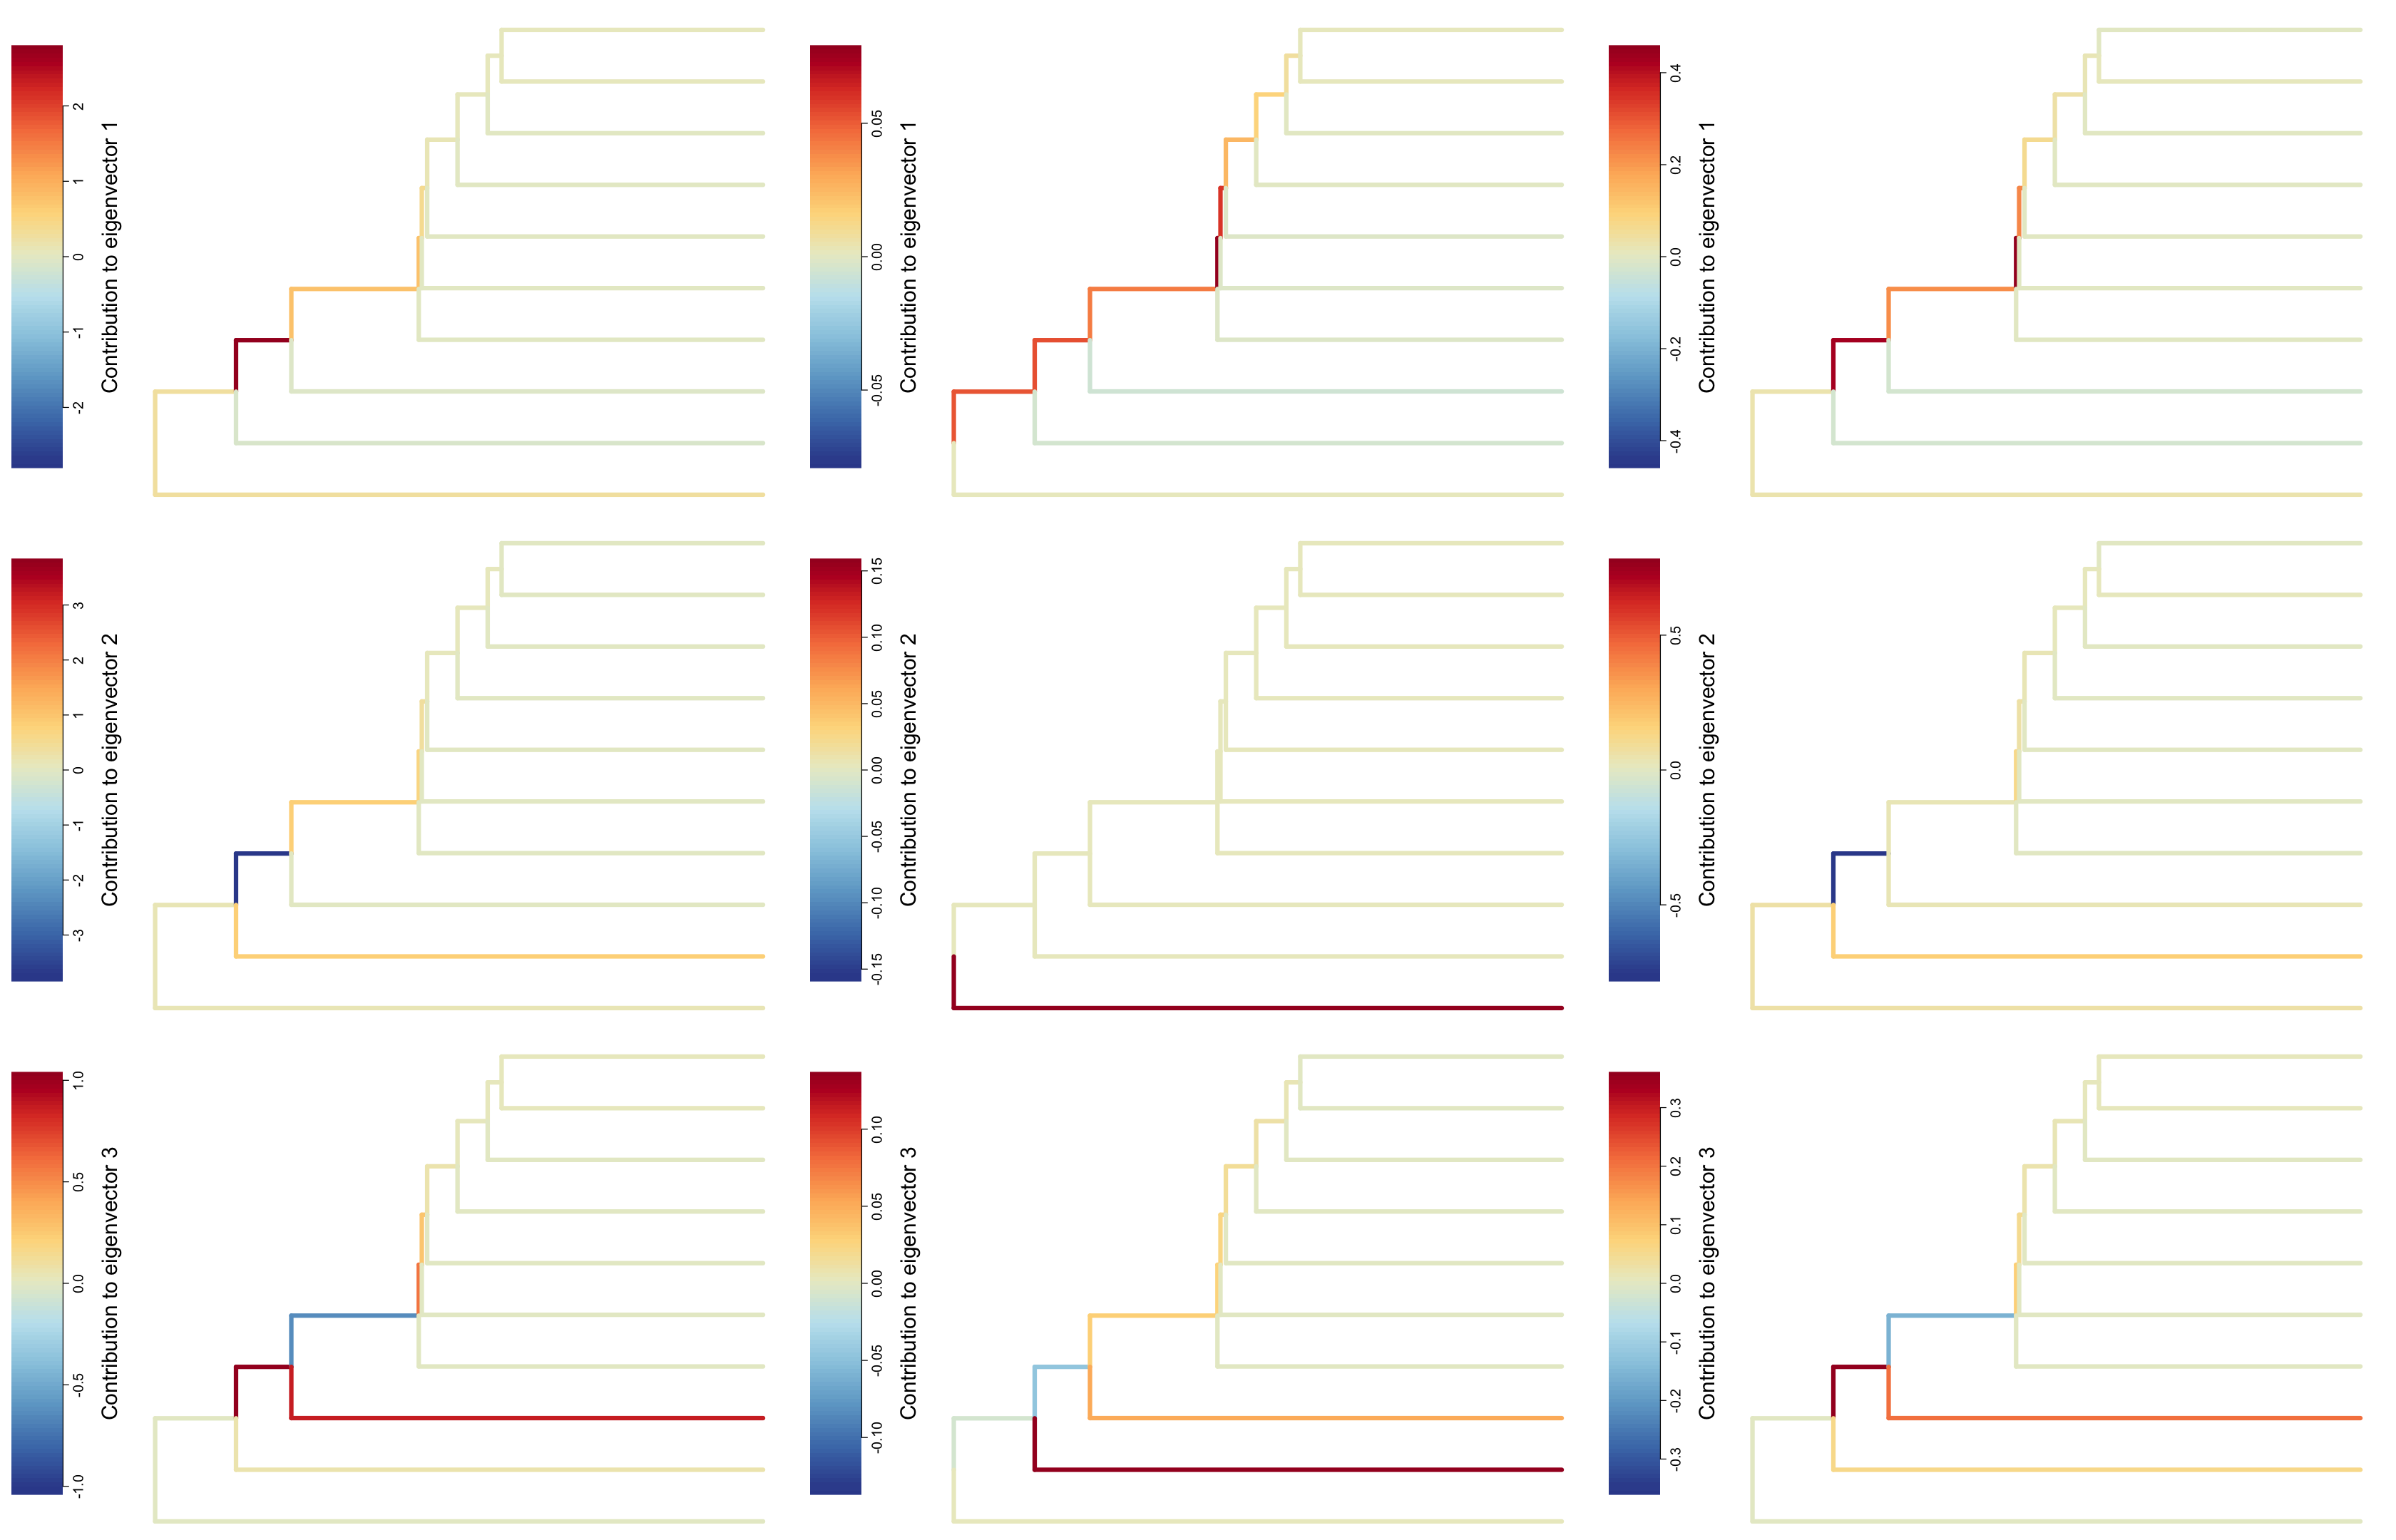

In [51]:
options(repr.plot.width = 28, repr.plot.height = 18)
layout(matrix(1:18, nrow = 3, byrow = TRUE), widths = c(3, 35, 3, 35, 3, 35)) 

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_1, z = matrix(color_breaks_2_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_eGRM_1, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_2, z = matrix(color_breaks_2_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_VCV_1, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_3, z = matrix(color_breaks_2_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_dcVCV_1, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_3_1, z = matrix(color_breaks_3_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 2", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_eGRM_2, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_3_2, z = matrix(color_breaks_3_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 2", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_VCV_2, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_3_3, z = matrix(color_breaks_3_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 2", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_dcVCV_2, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_4_1, z = matrix(color_breaks_4_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 3", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_eGRM_3, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_4_2, z = matrix(color_breaks_4_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 3", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_VCV_3, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_4_3, z = matrix(color_breaks_4_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 3", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_dcVCV_3, 
           edge.width = 5, show.tip.label = FALSE)

In [52]:
svg("Figures_raw/supplement_PC_contributions_3.svg", width = 28, height = 18)
layout(matrix(1:18, nrow = 3, byrow = TRUE), widths = c(3, 35, 3, 35, 3, 35)) 

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_1, z = matrix(color_breaks_2_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_eGRM_1, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_2, z = matrix(color_breaks_2_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_VCV_1, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_3, z = matrix(color_breaks_2_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_dcVCV_1, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_3_1, z = matrix(color_breaks_3_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 2", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_eGRM_2, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_3_2, z = matrix(color_breaks_3_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 2", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_VCV_2, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_3_3, z = matrix(color_breaks_3_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 2", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_dcVCV_2, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_4_1, z = matrix(color_breaks_4_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 3", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_eGRM_3, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_4_2, z = matrix(color_breaks_4_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 3", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_VCV_3, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_4_3, z = matrix(color_breaks_4_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 3", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_dcVCV_3, 
           edge.width = 5, show.tip.label = FALSE)

dev.off()

pdf 
  2

In [53]:
pdf("Figures_raw/supplement_PC_contributions_3.pdf", width = 28, height = 18)
layout(matrix(1:18, nrow = 3, byrow = TRUE), widths = c(3, 35, 3, 35, 3, 35)) 

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_1, z = matrix(color_breaks_2_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_eGRM_1, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_2, z = matrix(color_breaks_2_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_VCV_1, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2_3, z = matrix(color_breaks_2_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 1", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_dcVCV_1, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_3_1, z = matrix(color_breaks_3_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 2", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_eGRM_2, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_3_2, z = matrix(color_breaks_3_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 2", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_VCV_2, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_3_3, z = matrix(color_breaks_3_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 2", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_dcVCV_2, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_4_1, z = matrix(color_breaks_4_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 3", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_eGRM_3, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_4_2, z = matrix(color_breaks_4_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 3", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_VCV_3, 
           edge.width = 5, show.tip.label = FALSE)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_4_3, z = matrix(color_breaks_4_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 1.5)
mtext("Contribution to eigenvector 3", side = 4, line = 4, cex = 1.5)
par(mar = c(0, 6, 1, 1))
plot.phylo(pect_tree, edge.color = branch_colors_pect_dcVCV_3, 
           edge.width = 5, show.tip.label = FALSE)

dev.off()

pdf 
  2